# PS5 Q3.1: Transition Dynamics after a TFP Shock (Aiyagari Model)

Compute the transition path following a 10% TFP shock using the shooting method
and root-finding alternative. The shock is mean-reverting:

$$\log Z_1 = 0, \quad \log Z_2 = 0.10, \quad \log Z_t = 0.95 \log Z_{t-1} \; (t \geq 3)$$

In [3]:
import importlib
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Repo-root detection: walk up from cwd, then search 1-2 levels down
REPO_ROOT = None
for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "hetmacro").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    for depth in ["*/hetmacro", "*/*/hetmacro"]:
        hits = list(Path.cwd().resolve().glob(depth))
        if hits:
            REPO_ROOT = hits[0].parent
            break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hetmacro.transition
import hetmacro.models.aiyagari
importlib.reload(hetmacro.transition)
importlib.reload(hetmacro.models.aiyagari)

from hetmacro.grids import make_asset_grid
from hetmacro.income_process import RouwenhorstIncome
from hetmacro.markov import stationary_distribution
from hetmacro.models.aiyagari import firm_k_demand, firm_wage
from hetmacro.steady_state import household_steady_state
from hetmacro.transition import compute_transition_path, diagnose_transition
from hetmacro.optimize import brentq

## 1. Calibration and Steady State

In [4]:
# PS5 parameterization
beta = 0.99
gamma = 1.5          # CRRA
eis = 1.0 / gamma    # elasticity of intertemporal substitution
rho = 0.99
sigma_e = 0.10
alpha = 0.35
delta = 0.02

# Grid
nk = 501
ne = 11
k_min, k_max = 0.0, 2500.0
a_grid = make_asset_grid(k_min, k_max, nk, curvature=2.0)

# Income process (Rouwenhorst, normalized so E[z]=1)
income = RouwenhorstIncome.from_ar1(n=ne, rho=rho, sigma=sigma_e)
pi_stat = stationary_distribution(income.Pi, method="iterate")
mean_z = float(np.dot(pi_stat, income.z_grid))
income.z_grid = income.z_grid / mean_z

Pi = income.Pi
z_grid = income.z_grid

print(f"Asset grid: {nk} points on [{k_min}, {k_max}]")
print(f"Income states: {ne}, z in [{z_grid.min():.4f}, {z_grid.max():.4f}]")
print(f"E[z] = {np.dot(pi_stat, z_grid):.6f}")

Asset grid: 501 points on [0.0, 2500.0]
Income states: 11, z in [0.0828, 7.3338]
E[z] = 1.000000


In [5]:
# Find GE steady-state interest rate
def excess_demand(r):
    K_d = firm_k_demand(r, alpha, delta)
    w = firm_wage(K_d, alpha)
    ss = household_steady_state(Pi, a_grid, w * z_grid, r, beta, eis)
    return ss["A"] - K_d

r_upper = 1.0 / beta - 1.0 - 1e-4
print("Finding steady-state interest rate...")
t0 = time.time()
r_star = brentq(excess_demand, 0.001, r_upper, tol=1e-8)
print(f"  Elapsed: {time.time() - t0:.1f}s")

K_ss = firm_k_demand(r_star, alpha, delta)
w_ss = firm_wage(K_ss, alpha)
Y_ss = K_ss ** alpha
ss = household_steady_state(Pi, a_grid, w_ss * z_grid, r_star, beta, eis)

print(f"\nSteady state:")
print(f"  r* = {r_star:.6f}")
print(f"  K  = {K_ss:.4f}")
print(f"  w  = {w_ss:.4f}")
print(f"  Y  = {Y_ss:.4f}")
print(f"  C  = {ss['C']:.4f}")
print(f"  K_s (supply) = {ss['A']:.4f}")
print(f"  RC = Y - C - delta*K = {Y_ss - ss['C'] - delta * K_ss:.6f}")

Finding steady-state interest rate...
  Elapsed: 2.0s

Steady state:
  r* = 0.004752
  K  = 58.8756
  w  = 2.7064
  Y  = 4.1637
  C  = 2.9862
  K_s (supply) = 58.8756
  RC = Y - C - delta*K = -0.000000


## 2. TFP Shock Path

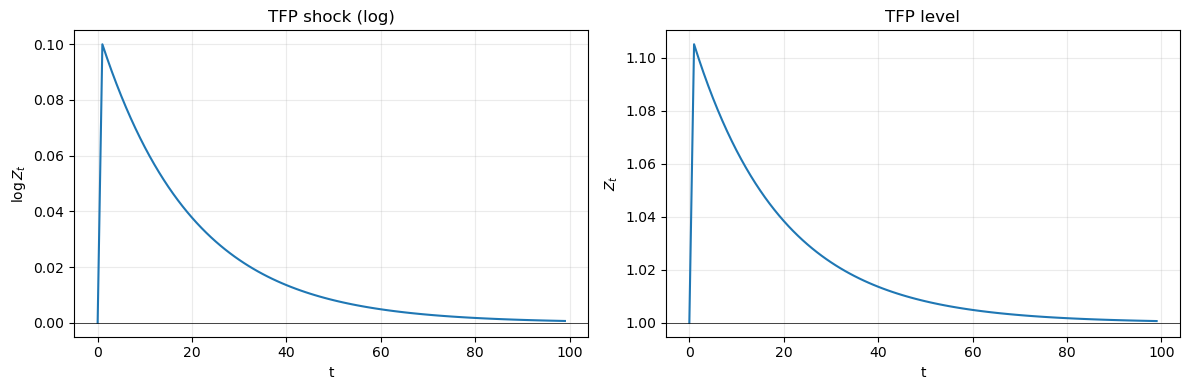

In [6]:
# PS5 Q3.1: 10% TFP shock, AR(1) with persistence 0.95
T = 300
log_Z = np.zeros(T)
log_Z[1] = 0.10       # shock at t=1
for t in range(2, T):
    log_Z[t] = 0.95 * log_Z[t - 1]
Z_path = np.exp(log_Z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(log_Z[:100])
ax1.set_xlabel("t")
ax1.set_ylabel(r"$\log Z_t$")
ax1.set_title("TFP shock (log)")
ax1.axhline(0, color="k", linewidth=0.5)
ax1.grid(alpha=0.25)

ax2.plot(Z_path[:100])
ax2.set_xlabel("t")
ax2.set_ylabel(r"$Z_t$")
ax2.set_title("TFP level")
ax2.axhline(1, color="k", linewidth=0.5)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 3. Transition Path: Shooting Method

The shooting algorithm:
1. Guess a capital path $\{K_t\}_{t=0}^{T-1}$
2. Compute prices $r_t, w_t$ from $K_t$ and $Z_t$
3. Backward iterate value/policy functions from terminal SS
4. Forward iterate distributions from initial SS
5. Compute implied capital path, update guess with damping

Damping convention: `damping` = weight on old guess. Virgiliu's step = 1/3 corresponds to `damping = 2/3`.

  Initial SS: K=58.8756  r=0.004752  C=2.9862
  Terminal SS: K=58.8756  (same as initial, mean-reverting shock)
  Transition iter   1: max|K_new - K_old| = 5.8208e+00  mean|K_new - K_old| = 3.0919e+00
  Transition iter   2: max|K_new - K_old| = 2.3058e+00  mean|K_new - K_old| = 1.2464e+00
  Transition iter   3: max|K_new - K_old| = 1.2926e+00  mean|K_new - K_old| = 3.1933e-01
  Transition iter   4: max|K_new - K_old| = 7.2293e-01  mean|K_new - K_old| = 1.8073e-01
  Transition iter   5: max|K_new - K_old| = 4.2215e-01  mean|K_new - K_old| = 1.0063e-01
  Transition iter   6: max|K_new - K_old| = 2.5093e-01  mean|K_new - K_old| = 5.6116e-02
  Transition iter   7: max|K_new - K_old| = 1.5139e-01  mean|K_new - K_old| = 3.1571e-02
  Transition iter   8: max|K_new - K_old| = 9.2294e-02  mean|K_new - K_old| = 1.7962e-02
  Transition iter   9: max|K_new - K_old| = 5.6709e-02  mean|K_new - K_old| = 1.0403e-02
  Transition iter  10: max|K_new - K_old| = 3.5057e-02  mean|K_new - K_old| = 6.2092e-0

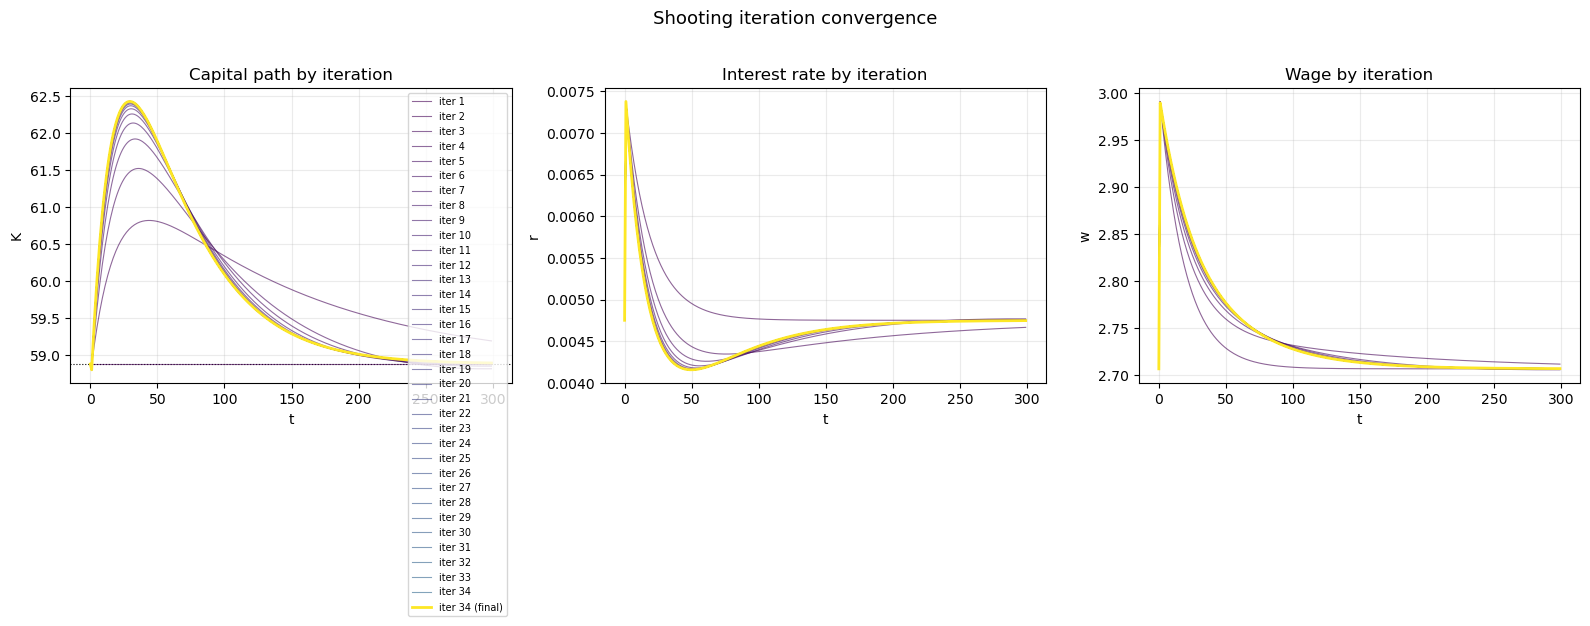


Elapsed: 7.5s
K range: [58.7974, 62.4235]


In [7]:
# Price function: maps (K, t) to household inputs
def price_fn(K, t):
    Z = float(Z_path[t])
    r = Z * alpha * K ** (alpha - 1.0) - delta
    w = Z * (1.0 - alpha) * K ** alpha
    Y = Z * K ** alpha
    return {"r": r, "y": w * z_grid, "w": w, "Y": Y}

# Shooting with damping = 2/3 (Virgiliu step = 1/3)
print(f"Shooting method: T={T}, damping=2/3")
print("=" * 60)
t0 = time.time()
result_shoot = compute_transition_path(
    ss_initial=ss,
    ss_terminal=ss,
    price_fn=price_fn,
    T=T,
    method="shooting",
    damping=2 / 3,
    tol=1e-6,
    max_iter=100,
    verbose=True,
    plot_iterations=True,
)
elapsed_shoot = time.time() - t0
print(f"\nElapsed: {elapsed_shoot:.1f}s")
print(f"K range: [{result_shoot.K_path.min():.4f}, {result_shoot.K_path.max():.4f}]")

## 4. Impulse Response Functions

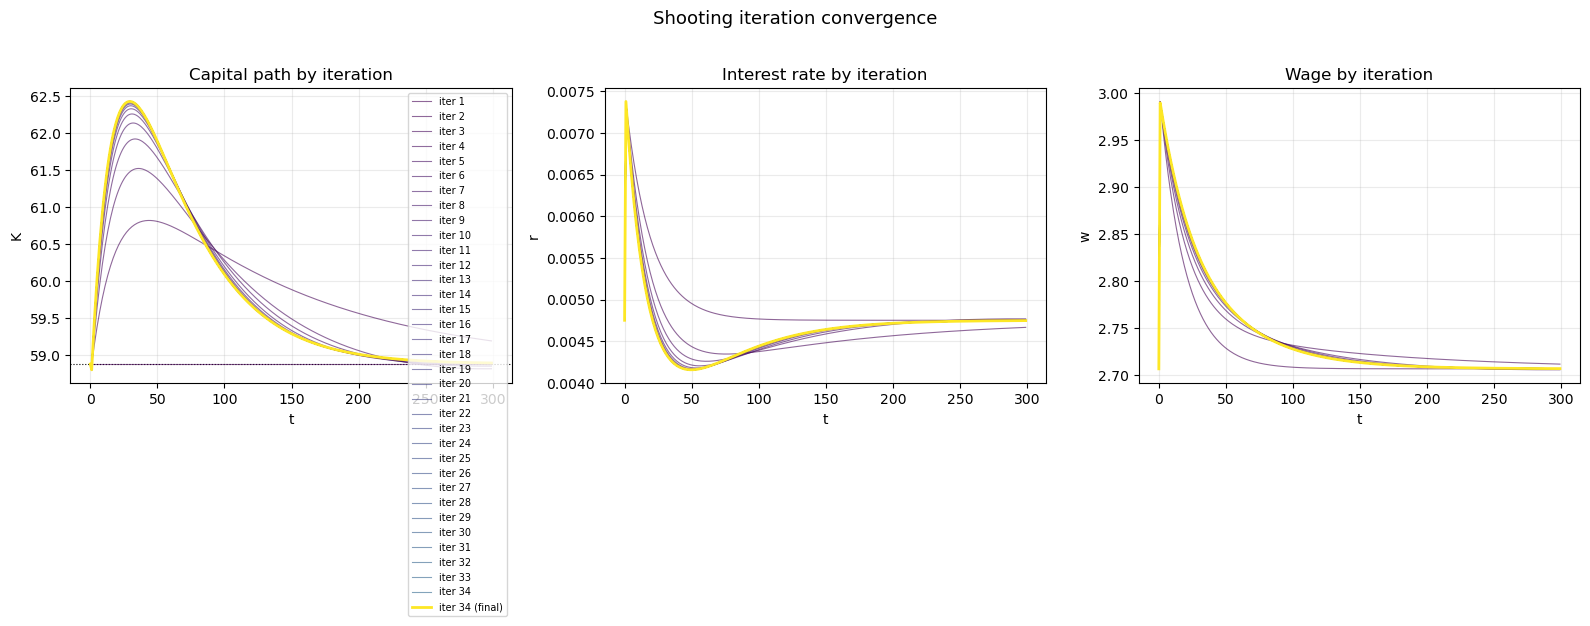

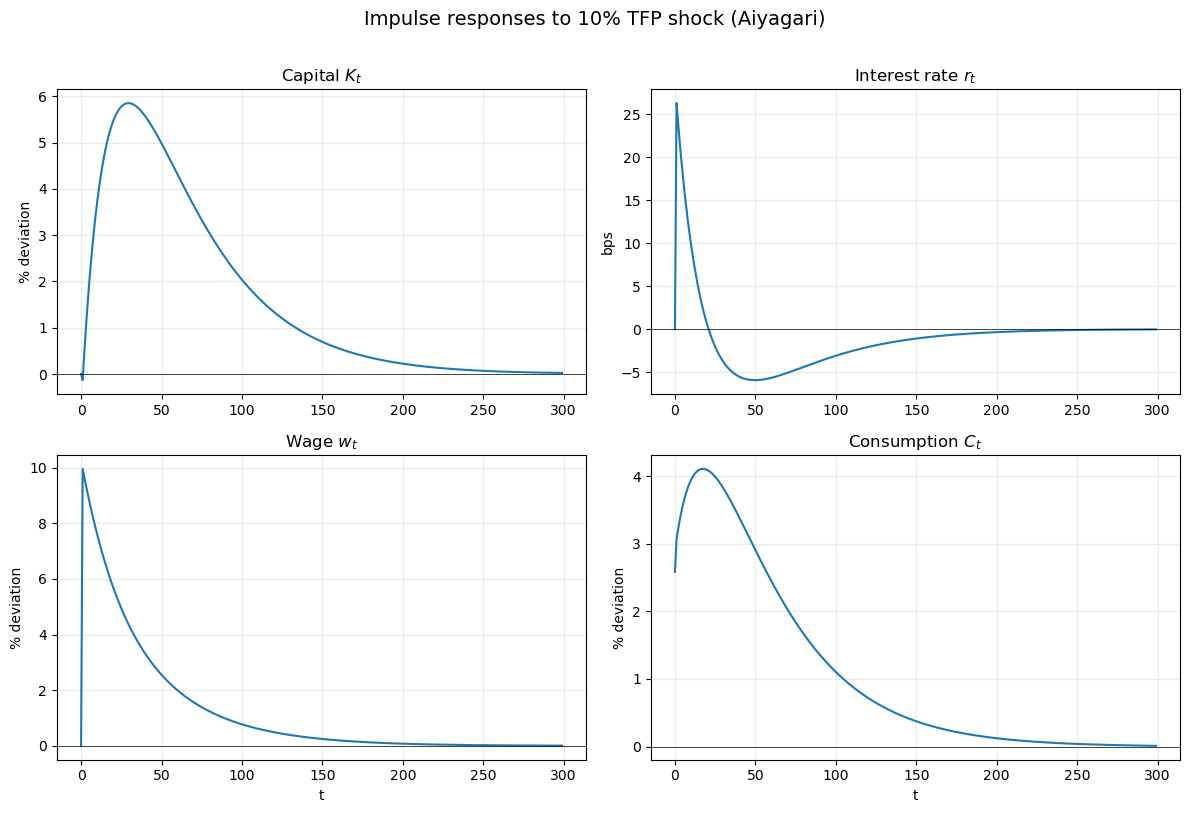

In [9]:
res = result_shoot
t_plot = T  # periods to plot

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Capital (log deviation from SS)
axs[0, 0].plot(np.log(res.K_path[:t_plot] / K_ss) * 100)
axs[0, 0].set_ylabel("% deviation")
axs[0, 0].set_title(r"Capital $K_t$")
axs[0, 0].axhline(0, color="k", linewidth=0.5)
axs[0, 0].grid(alpha=0.25)

# Interest rate (basis points from SS)
axs[0, 1].plot((res.r_path[:t_plot] - r_star) * 10_000)
axs[0, 1].set_ylabel("bps")
axs[0, 1].set_title(r"Interest rate $r_t$")
axs[0, 1].axhline(0, color="k", linewidth=0.5)
axs[0, 1].grid(alpha=0.25)

# Wage (log deviation)
axs[1, 0].plot(np.log(res.w_path[:t_plot] / w_ss) * 100)
axs[1, 0].set_ylabel("% deviation")
axs[1, 0].set_title(r"Wage $w_t$")
axs[1, 0].set_xlabel("t")
axs[1, 0].axhline(0, color="k", linewidth=0.5)
axs[1, 0].grid(alpha=0.25)

# Consumption (log deviation)
axs[1, 1].plot(np.log(res.C_path[:t_plot] / ss["C"]) * 100)
axs[1, 1].set_ylabel("% deviation")
axs[1, 1].set_title(r"Consumption $C_t$")
axs[1, 1].set_xlabel("t")
axs[1, 1].axhline(0, color="k", linewidth=0.5)
axs[1, 1].grid(alpha=0.25)

fig.suptitle("Impulse responses to 10% TFP shock (Aiyagari)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Diagnostics

In [11]:
diag = diagnose_transition(result_shoot, ss, ss, price_fn, alpha=alpha, delta=delta)


  ── Transition diagnostics ──
  Resource constraint:  max|RC_t| = 2.5872e-10
  Distribution mass:    max|sum-1| = 4.1966e-14
  K boundary:           start dev = 1.4162e-09, end dev = 2.3719e-04



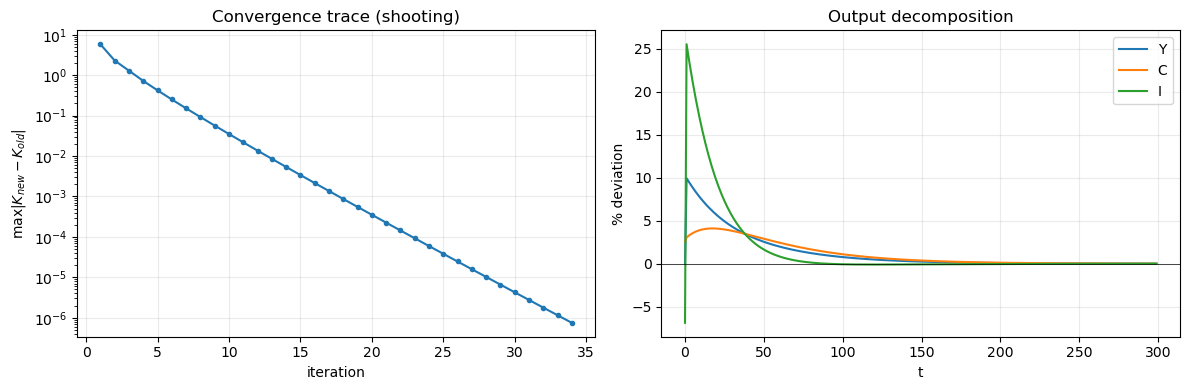

In [12]:
# Convergence trace
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(res.error_history) + 1), res.error_history, "o-", markersize=3)
ax1.set_yscale("log")
ax1.set_xlabel("iteration")
ax1.set_ylabel(r"max$|K_{new} - K_{old}|$")
ax1.set_title("Convergence trace (shooting)")
ax1.grid(alpha=0.25)

# Output and investment
Y_path = np.array([price_fn(res.K_path[t], t)["Y"] for t in range(T)])
I_path = Y_path - res.C_path  # investment = Y - C
ax2.plot(np.log(Y_path[:t_plot] / Y_ss) * 100, label="Y")
ax2.plot(np.log(res.C_path[:t_plot] / ss["C"]) * 100, label="C")
ax2.plot(np.log(I_path[:t_plot] / (Y_ss - ss["C"])) * 100, label="I")
ax2.set_xlabel("t")
ax2.set_ylabel("% deviation")
ax2.set_title("Output decomposition")
ax2.legend()
ax2.axhline(0, color="k", linewidth=0.5)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Root-Finding Method (Broyden)

Alternative: solve for the capital path that clears markets at every date simultaneously,
using Broyden's method (quasi-Newton with rank-1 Jacobian updates).

In [13]:
# Root-finding with shorter horizon for speed
T_rf = T
Z_path_rf = Z_path[:T_rf]

def price_fn_rf(K, t):
    Z = float(Z_path_rf[t])
    r = Z * alpha * K ** (alpha - 1.0) - delta
    w = Z * (1.0 - alpha) * K ** alpha
    Y = Z * K ** alpha
    return {"r": r, "y": w * z_grid, "w": w, "Y": Y}

print(f"Root-finding (Broyden): T={T_rf}")
print("=" * 60)
t0 = time.time()
result_root = compute_transition_path(
    ss_initial=ss,
    ss_terminal=ss,
    price_fn=price_fn_rf,
    T=T_rf,
    method="root_finding",
    tol=1e-6,
    max_iter=50,
    verbose=True,
)
elapsed_root = time.time() - t0
print(f"\nElapsed: {elapsed_root:.1f}s")
print(f"Converged: {result_root.converged}")

Root-finding (Broyden): T=300
  Initial SS: K=58.8756  r=0.004752  C=2.9862
  Terminal SS: K=58.8756
  Root-finding with T=300 unknowns...
  Root eval   1: max|residual| = 5.8208e+00
  Root eval   2: max|residual| = 7.5841e+01
  Root eval   3: max|residual| = 5.6258e+00
  Root eval   4: max|residual| = 6.2089e+01
  Root eval   5: max|residual| = 5.5347e+00
  Root eval   6: max|residual| = 6.2089e+01
  Root eval   7: max|residual| = 1.4996e+01
  Root eval   8: max|residual| = 1.0704e+02
  Root eval   9: max|residual| = 1.3717e+01
  Root eval  10: max|residual| = 1.4898e+01
  Root eval  11: max|residual| = 9.0333e+00
  Root eval  12: max|residual| = 5.8853e+00
  Root eval  13: max|residual| = 1.3109e+01
  Root eval  14: max|residual| = 4.9391e+00
  Root eval  15: max|residual| = 2.2255e+00
  Root eval  16: max|residual| = 6.0254e+00
  Root eval  17: max|residual| = 1.8724e+00
  Root eval  18: max|residual| = 7.1356e-01
  Root eval  19: max|residual| = 3.3246e+00
  Root eval  20: max|resi

## 7. Shooting vs Root-Finding Comparison

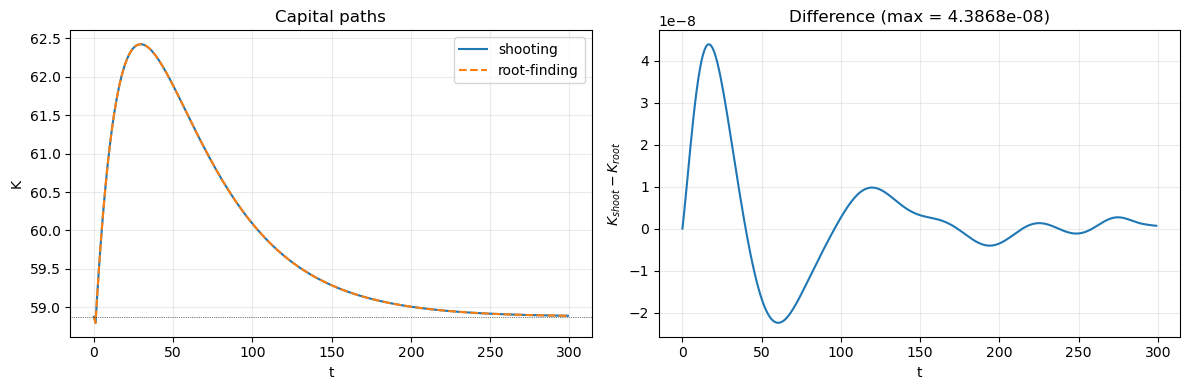

Method comparison (first 300 periods):
  max|K_shoot - K_root| = 4.3868e-08
  Shooting: 34 iters, 7.5s
  Root-finding: 45 evals, 5.9s


In [14]:
# Compare shooting and root-finding over the common horizon T_rf
K_shoot_short = result_shoot.K_path[:T_rf]
K_root = result_root.K_path

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_shoot_short[:T], label="shooting")
ax1.plot(K_root[:T], "--", label="root-finding")
ax1.axhline(K_ss, color="k", linewidth=0.5, linestyle=":")
ax1.set_xlabel("t")
ax1.set_ylabel("K")
ax1.set_title("Capital paths")
ax1.legend()
ax1.grid(alpha=0.25)

diff = K_shoot_short - K_root
ax2.plot(diff)
ax2.set_xlabel("t")
ax2.set_ylabel(r"$K_{shoot} - K_{root}$")
ax2.set_title(f"Difference (max = {np.max(np.abs(diff)):.4e})")
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Method comparison (first {T_rf} periods):")
print(f"  max|K_shoot - K_root| = {np.max(np.abs(diff)):.4e}")
print(f"  Shooting: {result_shoot.n_iterations} iters, {elapsed_shoot:.1f}s")
print(f"  Root-finding: {result_root.n_iterations} evals, {elapsed_root:.1f}s")

## 8. Alternative Formulation: Root-Finding over Interest Rates

The K-based Broyden solves $F(\mathbf{K}) = \mathbf{K}^{\text{implied}} - \mathbf{K} = 0$, which is essentially
the shooting iteration with Broyden replacing the damped update.

A more natural formulation mirrors the steady-state bisection directly: guess the
interest rate path $\{r_t\}$, compute capital demand $K^d_t(r_t)$ from the firm FOC
and capital supply $K^s_t$ from backward-forward, then solve the excess demand system:

$$F(\mathbf{r}) = \mathbf{K}^s(\mathbf{r}) - \mathbf{K}^d(\mathbf{r}) = 0$$

where $K^d_t = \left(\frac{Z_t \alpha}{r_t + \delta}\right)^{1/(1-\alpha)}$ and $K^s_t = \sum_{a,z} a \cdot D_t(a,z)$.

**Rescaling:** Since $r \sim 0.005$ but $K \sim 60$, the identity initial Jacobian is off by $\sim 10^3$.
We rescale the search variable: $x = (r - r^{ss}) \cdot \kappa$ where $\kappa = K^{ss} / [(r^{ss} + \delta)(1-\alpha)]$,
so that inputs and residuals are both $O(K^{ss})$.

In [15]:
from scipy.optimize import root
from hetmacro.transition import _backward_path, _forward_path

# Ingredients from steady state
Va_terminal = ss["Va"]
D_initial = ss["D"]

# Rescaling factor: dK^d/dr ≈ -K_ss / ((r_star + delta)(1-alpha))
scale_r = K_ss / ((r_star + delta) * (1.0 - alpha))
print(f"Rescaling factor: {scale_r:.1f}")

eval_count = [0]

def residual_r(x_vec):
    """Excess demand in rescaled coordinates.
    
    Search variable: x = (r - r_star) * scale_r  (so x ~ O(K_ss) near solution)
    Residual: K^s - K^d  (also O(K_ss))
    """
    eval_count[0] += 1
    
    # Unscale: r = r_star + x / scale_r
    r_vec = r_star + x_vec / scale_r
    r_vec = np.clip(r_vec, -delta + 1e-6, None)  # keep r + delta > 0
    
    # Capital demand and wages from firm FOC
    prices_path = []
    K_d = np.empty(T)
    for t in range(T):
        Z = float(Z_path[t])
        r_t = float(r_vec[t])
        K_d_t = (Z * alpha / (r_t + delta)) ** (1.0 / (1.0 - alpha))
        w_t = Z * (1.0 - alpha) * K_d_t ** alpha
        K_d[t] = K_d_t
        prices_path.append({"r": r_t, "y": w_t * z_grid})
    
    # Backward EGM → policies, Forward → K^s
    policies, _ = _backward_path(Va_terminal, prices_path, Pi, a_grid, beta, eis)
    K_s, _, _ = _forward_path(D_initial, policies, Pi, a_grid)
    
    res = K_s - K_d
    if eval_count[0] <= 5 or eval_count[0] % 10 == 0:
        print(f"  r-eval {eval_count[0]:3d}: max|residual| = {np.max(np.abs(res)):.4e}")
    return res

# Initial guess: flat at SS rate → x = 0
x0 = np.zeros(T)

print(f"\nBroyden over r (rescaled): T={T}")
print("=" * 60)
t0 = time.time()
sol = root(
    residual_r, x0, method="broyden1",
    options={"maxiter": 200, "fatol": 1e-6, "line_search": "armijo"},
)
elapsed_r = time.time() - t0

print(f"\nConverged: {sol.success}")
print(f"{eval_count[0]} evals, {elapsed_r:.1f}s")
print(f"max|residual| = {np.max(np.abs(sol.fun)):.4e}")

# Recover K path from converged r
r_converged = r_star + sol.x / scale_r
K_from_r = np.array([
    (Z_path[t] * alpha / (r_converged[t] + delta)) ** (1.0 / (1.0 - alpha))
    for t in range(T)
])

Rescaling factor: 3659.4

Broyden over r (rescaled): T=300
  r-eval   1: max|residual| = 9.8795e+00
  r-eval   2: max|residual| = 1.0006e+01
  r-eval   3: max|residual| = 9.9391e+00
  r-eval   4: max|residual| = 9.9031e+00
  r-eval   5: max|residual| = 9.8914e+00
  r-eval  10: max|residual| = 1.0006e+01
  r-eval  20: max|residual| = 5.7514e+00
  r-eval  30: max|residual| = 1.6121e+00
  r-eval  40: max|residual| = 1.6122e+00
  r-eval  50: max|residual| = 2.0450e+00
  r-eval  60: max|residual| = 2.1682e+00
  r-eval  70: max|residual| = 2.7482e-01
  r-eval  80: max|residual| = 3.0661e-01
  r-eval  90: max|residual| = 3.2925e-01
  r-eval 100: max|residual| = 7.6812e-02
  r-eval 110: max|residual| = 6.5006e-02
  r-eval 120: max|residual| = 7.0973e-02
  r-eval 130: max|residual| = 7.3687e-02
  r-eval 140: max|residual| = 7.2254e-02
  r-eval 150: max|residual| = 7.2891e-02
  r-eval 160: max|residual| = 8.1068e-02
  r-eval 170: max|residual| = 1.0091e-02
  r-eval 180: max|residual| = 1.0287e-0

## 9. Three-Way Comparison

All three methods solve the same equilibrium. The differences are:
- **Shooting**: damped fixed-point iteration over $K$. Simple, linear convergence.
- **Broyden over $K$**: $F(K) = K^{\text{implied}} - K$. Quasi-Newton, superlinear convergence. Same residual as shooting but with smarter updates.
- **Broyden over $r$**: $F(r) = K^s(r) - K^d(r)$. Economically natural (mirrors SS bisection), but worse Jacobian conditioning requires rescaling and more iterations.

Pairwise differences in capital paths:
  max|K_Broyden(K) - K_Broyden(r)| = 9.5382e-07
  max|K_shooting  - K_Broyden(r)| = 9.6106e-07
  max|K_shooting  - K_Broyden(K)| = 4.3868e-08

Performance:
  Shooting:    34 iters,  7.5s
  Broyden(K):  45 evals,  5.9s
  Broyden(r):  438 evals,  56.1s


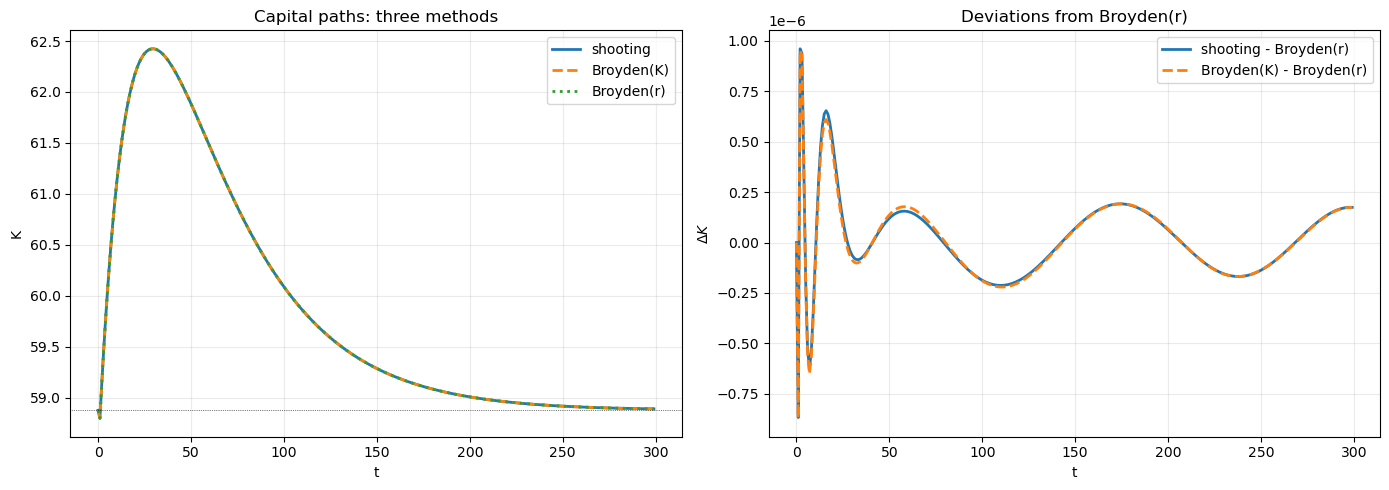

In [16]:
# ── Equivalence check ──
diff_K_vs_r = np.max(np.abs(result_root.K_path - K_from_r))
diff_shoot_vs_r = np.max(np.abs(result_shoot.K_path - K_from_r))
diff_shoot_vs_K = np.max(np.abs(result_shoot.K_path - result_root.K_path))

print("Pairwise differences in capital paths:")
print(f"  max|K_Broyden(K) - K_Broyden(r)| = {diff_K_vs_r:.4e}")
print(f"  max|K_shooting  - K_Broyden(r)| = {diff_shoot_vs_r:.4e}")
print(f"  max|K_shooting  - K_Broyden(K)| = {diff_shoot_vs_K:.4e}")

print(f"\nPerformance:")
print(f"  Shooting:    {result_shoot.n_iterations} iters,  {elapsed_shoot:.1f}s")
print(f"  Broyden(K):  {result_root.n_iterations} evals,  {elapsed_root:.1f}s")
print(f"  Broyden(r):  {eval_count[0]} evals,  {elapsed_r:.1f}s")

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(result_shoot.K_path, label="shooting", linewidth=2)
ax1.plot(result_root.K_path, "--", label="Broyden(K)", linewidth=2)
ax1.plot(K_from_r, ":", label="Broyden(r)", linewidth=2)
ax1.axhline(K_ss, color="k", linewidth=0.5, linestyle=":")
ax1.set_xlabel("t"); ax1.set_ylabel("K")
ax1.set_title("Capital paths: three methods")
ax1.legend(); ax1.grid(alpha=0.25)

# Differences relative to Broyden(r)
ax2.plot(result_shoot.K_path - K_from_r, label="shooting - Broyden(r)", linewidth=2)
ax2.plot(result_root.K_path - K_from_r, "--", label="Broyden(K) - Broyden(r)", linewidth=2)
ax2.set_xlabel("t"); ax2.set_ylabel(r"$\Delta K$")
ax2.set_title("Deviations from Broyden(r)")
ax2.legend(); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()